In [1]:
import pandas as pd
import matplotlib.ticker as mticker
import numpy as np
import networkx as nx
import matplotlib.patches as mpatches
import dowhy
from IPython.display import Image

/home/yash/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "text.usetex"           : True, 
})

# Part 0: Data Familiarisation 

In [3]:
data = pd.read_csv("data_dengue_net_v2.csv", index_col = [0])
data["income"] = data["income"] * 10 # Scaling the Income colums to convert it into Rupees
sample_size = data.shape[0]

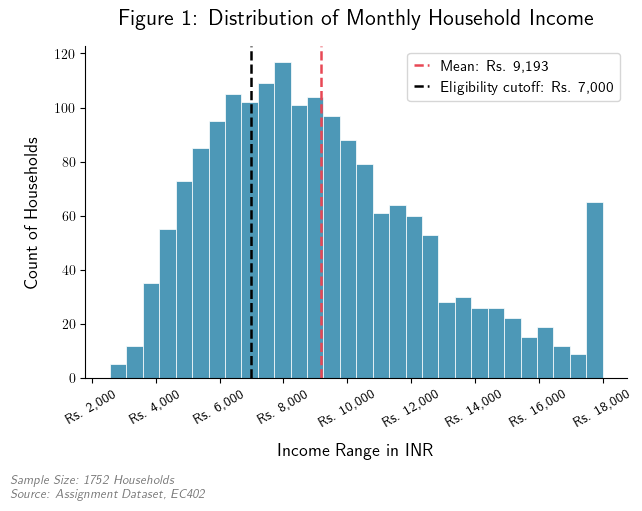

In [4]:
#plotting income distribution
fig, ax = plt.subplots()

ax.hist(data["income"], density=False, bins=30, color='#2E86AB', edgecolor='white', linewidth=0.6, alpha=0.85)
ax.set_ylabel(r"""{Count of Households}""", fontsize=13, labelpad=10)
ax.set_xlabel(r"""{Income Range in INR}""", fontsize=13, labelpad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rs. {x:,.0f}"))
ax.tick_params(axis='x', rotation=30)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

mean_val = data["income"].mean()
eligibility = 7000
ax.axvline(mean_val,    color="#E84855", linestyle="--", linewidth=1.8, label=f"Mean: Rs. {mean_val:,.0f}")
ax.axvline(eligibility, color="black",   linestyle="--", linewidth=1.8, label=f"Eligibility cutoff: Rs. {eligibility:,.0f}")
ax.legend(fontsize=11, handlelength=1)
fig.text(0, -0.02, r"""\textit{Sample Size: 1752 Households}""", fontsize=9, color="gray", ha='left')
fig.text(0, -0.05, r"""\textit{Source: Assignment Dataset, EC402}""", fontsize=9, color="gray", ha='left')
plt.title(r"""{Figure 1: Distribution of Monthly Household Income}""",  fontsize=16, fontweight="bold", pad=15);
plt.tight_layout()
plt.show()


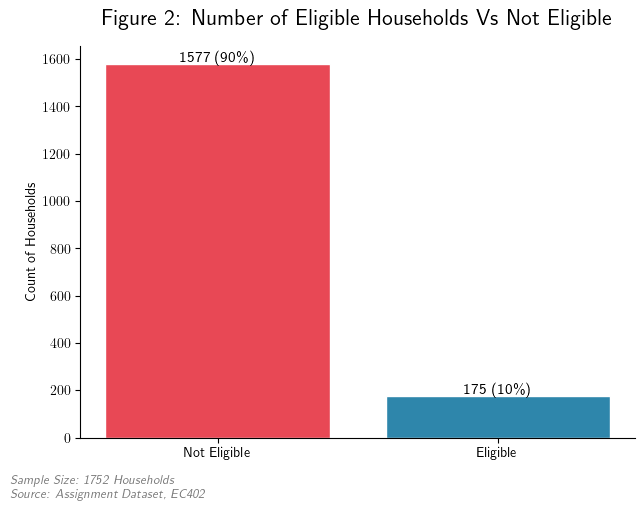

In [5]:
#Constructing the eligible variable
data["is_eligible"] = np.where( (data['income'] < 7000) & (data['household'] > 4), 1, 0)
counts = data["is_eligible"].value_counts().sort_index()
fig, ax = plt.subplots()
ax.bar(["Not Eligible", "Eligible"], counts, color=["#E84855", "#2E86AB"], edgecolor="white")
ax.set_ylabel("Count of Households")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.title("Figure 2: Number of Eligible Households Vs Not Eligible", fontweight="bold", fontsize=16, pad=15)
for i, val in enumerate(counts):
    ax.text(i, val + 10, f"{val} ({(val/sample_size)*100:.0f}\%)", ha="center", fontsize=11)
fig.text(0, -0.02, r"""\textit{Sample Size: 1752 Households}""", fontsize=9, color="gray", ha='left')
fig.text(0, -0.05, r"""\textit{Source: Assignment Dataset, EC402}""", fontsize=9, color="gray", ha='left')
plt.tight_layout()
plt.show()

In [6]:
#Comparing Mosquito Net Users Vs Not Users
data["is_netUser"] = np.where(data["net_num"] > 0, 1, 0)

variables = ["income", "dengue_risk", "household" , "health", 'temperature', 'resistance', 'rainfall']
summary_stats = {}

for var in variables:
    summary_stats[var] = data.groupby("is_netUser")[var].agg(
        count="count",
        mean="mean",
        std="std",
        min="min",
        max="max"
    )

summary_df = pd.concat(summary_stats, axis=0)
summary_df.index.names = ["variable", "is_netUser"]
summary_df.style.format("{:.2f}").set_caption("Summary Statistics by Internet Usage")

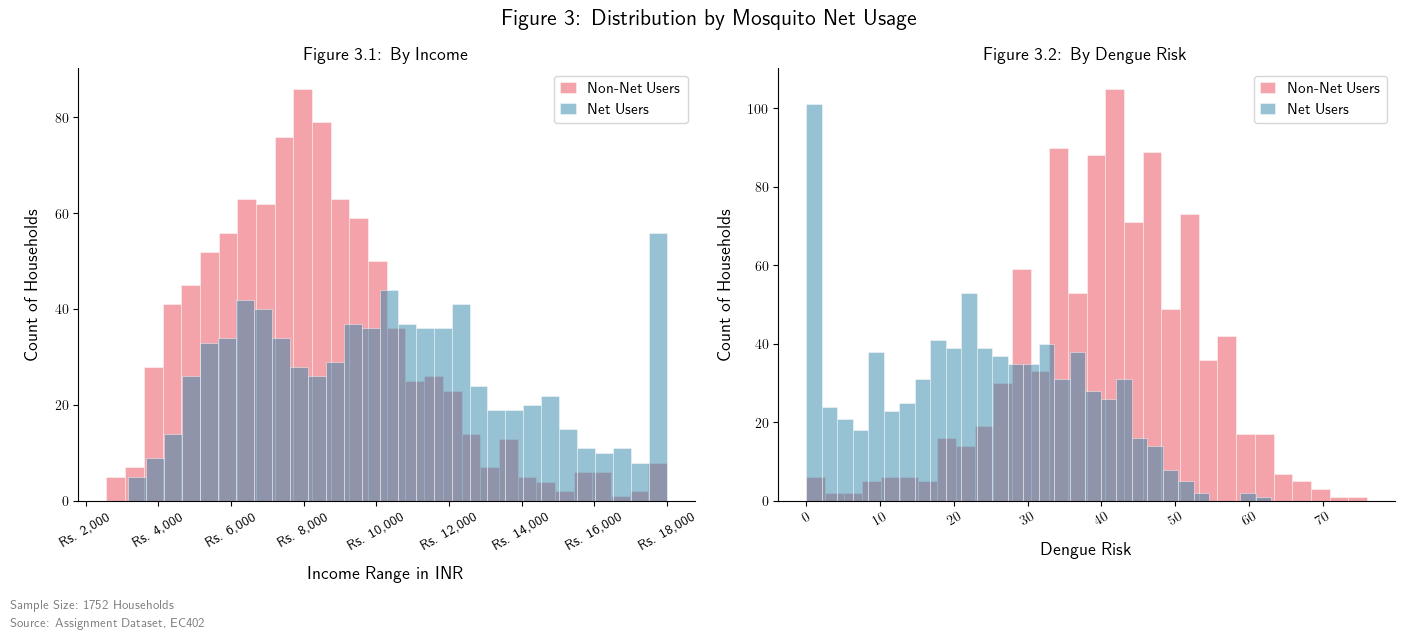

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Income
ax1.hist(data[data["is_netUser"] == 0]["income"], bins=30, color="#E84855", edgecolor="white",
        linewidth=0.6, alpha=0.5, label="Non-Net Users")
ax1.hist(data[data["is_netUser"] == 1]["income"], bins=30, color="#2E86AB", edgecolor="white",
        linewidth=0.6, alpha=0.5, label="Net Users")
ax1.set_ylabel("Count of Households", fontsize=13, labelpad=10)
ax1.set_xlabel("Income Range in INR", fontsize=13, labelpad=10)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rs. {x:,.0f}"))
ax1.tick_params(axis='x', rotation=30)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(fontsize=11, handlelength=1)
ax1.set_title("Figure 3.1: By Income", fontweight="bold", fontsize=13)

# Dengue Risk
ax2.hist(data[data["is_netUser"] == 0]["dengue_risk"], bins=30, color="#E84855", edgecolor="white",
        linewidth=0.6, alpha=0.5, label="Non-Net Users")
ax2.hist(data[data["is_netUser"] == 1]["dengue_risk"], bins=30, color="#2E86AB", edgecolor="white",
        linewidth=0.6, alpha=0.5, label="Net Users")
ax2.set_ylabel("Count of Households", fontsize=13, labelpad=10)
ax2.set_xlabel("Dengue Risk", fontsize=13, labelpad=10)
ax2.tick_params(axis='x', rotation=30)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(fontsize=11, handlelength=1)
ax2.set_title("Figure 3.2: By Dengue Risk", fontweight="bold", fontsize=13)

fig.suptitle("Figure 3: Distribution by Mosquito Net Usage", fontweight="bold", fontsize=16, x=0.5, ha = "center")
fig.text(0, -0.02, "Sample Size: 1752 Households", fontsize=9, color="gray", ha='left')
fig.text(0, -0.05, "Source: Assignment Dataset, EC402", fontsize=9, color="gray", ha='left')

plt.tight_layout()
plt.show()

# Part 1: Causal Framework

$\underline{\text{Research Question:}}$ $\text{What is the causal impact of using mosquito net on contracting dengue fever?}$ 

The figure below suggests that households (those who use the nets) only own multiple (>1) mosquito net if the Household size too big to accomodate all the members within a single Net. Hence, it is reasonable to assume that among those who use nets, none of them are "cramped up" in a single net reducing it's effectiveness, therefore we may define the treatment as a Binary variable indicating whether a Household uses a net or not (i.e. has more than or equal to one net).   

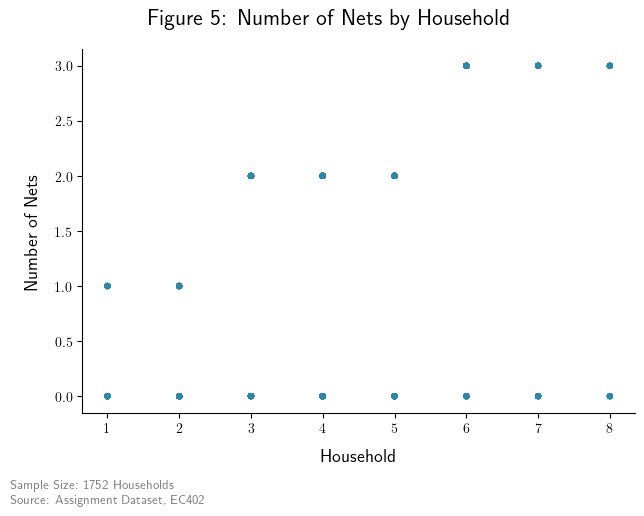

In [8]:
fig, ax = plt.subplots()

ax.scatter(data["household"], data["net_num"], color="#2E86AB", alpha=0.4, s=20, edgecolors="none")

ax.set_xlabel("Household", fontsize=13, labelpad=10)
ax.set_ylabel("Number of Nets", fontsize=13, labelpad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.suptitle("Figure 5: Number of Nets by Household", fontweight="bold", fontsize=16, x=0.5, ha="center")
fig.text(0, -0.02, "Sample Size: 1752 Households", fontsize=9, color="gray", ha='left')
fig.text(0, -0.05, "Source: Assignment Dataset, EC402", fontsize=9, color="gray", ha='left')

plt.tight_layout()
plt.show()

- The research question can be stated as: Does using a mosquito net causally reduce a household's risk of contracting dengue fever? In this context, it is more useful to calculate <b>ATE</b> as it tells us the effect of using a net versus not using a net **across the entire population**. If the ATE is negetive then we can generalise and say that using net reduces the risk of contracting the dengue fever. On the other hand, ATE tells us what the risk of contracting the dengue fever would have been had the individuals who used the net, not used it. Given the research question, the former is more meaningful as it pertains to the entire population and not just a part of it which takes the treatment (uses the net). 

- In fact, if we want to provide evidence in favour of using mosquito net to convince those individuals who don't use it, it is more appropriate to estimate the ATU, as it would tell us what how the people not taking the treatment (not using the net) would benefit (in terms of risk of contracting the dengue fever) had they used the net. 

- Since, a priori we have no reason to believe homogenous treatment effects, the choice of estimand matters. Under the assumption of homogenous treatment effect, the estimates of ATE, ATU and ATT are all expected to be the same and hence the choice of estimand wouldn't have mattered.  

- For Regression and matching analysis **net** variable should be used as the treatment variable.

## Creating the DAG

In [20]:
graph = [
        ("is_netUser", "dengue_risk"),
        ("income", "is_netUser"),
        ("health", "dengue_risk"),
        ("income", "health"),
        ("income", "is_eligible"),
        ("household", "is_eligible"),
        ("household", "is_netUser"),
        ("household", "income"),
        ("temperature", "health"),
        ("temperature", "dengue_risk"),
        ("temperature", "income"),
        ("rainfall", "temperature"),
        ("rainfall", "dengue_risk"),
        ("rainfall", "is_netUser"),
        ("resistance", "dengue_risk"),
        ("resistance", "is_netUser"),
        ("is_eligible", "is_netUser"),
    ]

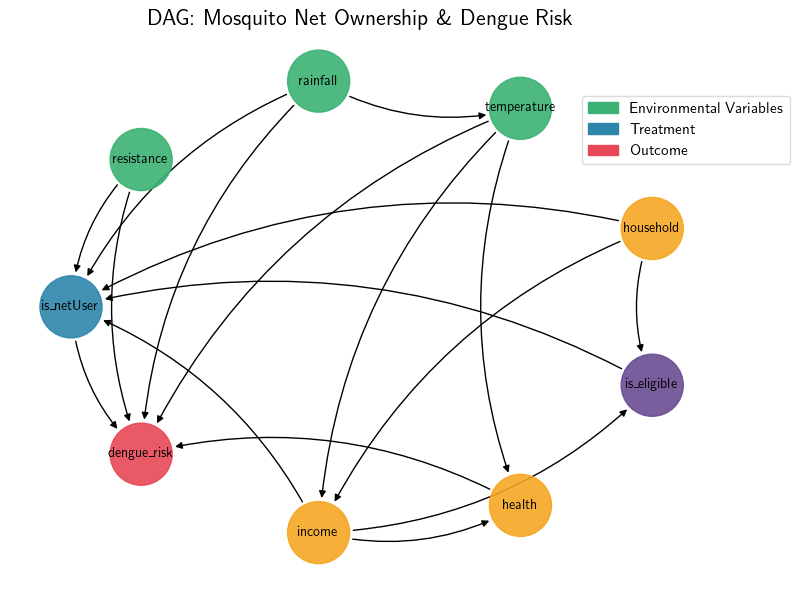

In [21]:
G = nx.DiGraph()
G.add_edges_from(graph)

node_colors = {
    "net_num"     : "#2E86AB",   # treatment
    "is_netUser"  : "#2E86AB",   # treatment (binary version)
    "dengue_risk" : "#E84855",   # outcome
    "income"      : "#F5A623",   # confounder
    "health"      : "#F5A623",   # confounder
    "household"   : "#F5A623",   # confounder
    "is_eligible" : "#6A4C93",   # instrument
    "temperature" : "#3BB273",   # environmental
    "resistance"  : "#3BB273",   # environmental
    "rainfall"    : "#3BB273",   # environmental
}

legend_elements = [
    mpatches.Patch(color="#3BB273", label="Environmental Variables"),
    mpatches.Patch(color="#2E86AB", label="Treatment"),
    mpatches.Patch(color="#E84855", label="Outcome"),
]

pos = nx.shell_layout(G) #shell_layout(G) #planar_layout(G) #nx.spring_layout(G, seed=42)  #nx.planar_layout(G)
fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_nodes(G, pos, node_color=[node_colors[n] for n in G.nodes()], node_size=2000, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_color="black", font_size=10, font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos, edge_color="black", arrows=True,
                       arrowstyle="-|>", arrowsize=10,
                       connectionstyle="arc3,rad=0.2", ax=ax, min_target_margin = 25, min_source_margin = 25 )

ax.set_title("DAG: Mosquito Net Ownership \& Dengue Risk", fontweight="bold", fontsize=16)
ax.legend(handles=legend_elements, fontsize=11, framealpha=0.7,loc="upper right", bbox_to_anchor=(1.12, 0.9))
ax.axis("off")
plt.tight_layout()
plt.show()

## Minimum Sufficient Adjustment Set

In [22]:
#get_immoralities()
from pgmpy.base import DAG
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference.CausalInference import CausalInference

model = DiscreteBayesianNetwork(graph)

causal = CausalInference(model)
adjustment_set = causal.get_minimal_adjustment_set(
    X="is_netUser",      # treatment
    Y="dengue_risk"      # outcome
)

print("Minimum Sufficient Adjustment Set:", adjustment_set)

Minimum Sufficient Adjustment Set: {'resistance', 'health', 'rainfall', 'temperature'}


## Back door Paths (Appendix)

In [23]:
from cgm import CausalGraphicalModel

cgm = CausalGraphicalModel(
    nodes=["is_netUser", "dengue_risk", "income", "health", "is_eligible", 
           "household", "temperature", "rainfall", "resistance"],
    edges=graph
)

# all backdoor paths
backdoor_paths = cgm.get_all_backdoor_paths(x="is_netUser", y="dengue_risk")
print("Backdoor Paths:")
for i, path in enumerate(backdoor_paths, 1):
    # Check actual edge direction for each step in the path
    path_str = []
    for a, b in zip(path[:-1], path[1:]):
        if cgm.dag.has_edge(a, b):
            path_str.append(f"{a} → {b}")
        else:
            path_str.append(f"{a} ← {b}")
    print(f"  {i}. {' | '.join(path_str)}")

# all valid backdoor adjustment sets
adjustment_sets = cgm.get_all_backdoor_adjustment_sets(x="is_netUser", y="dengue_risk")
print("\nValid Backdoor Adjustment Sets:")
for i, s in enumerate(adjustment_sets, 1):
    print(f"  {i}. {set(s)}")


Backdoor Paths:
  1. is_netUser ← income | income → health | health → dengue_risk
  2. is_netUser ← income | income → health | health ← temperature | temperature → dengue_risk
  3. is_netUser ← income | income → health | health ← temperature | temperature ← rainfall | rainfall → dengue_risk
  4. is_netUser ← income | income ← temperature | temperature → health | health → dengue_risk
  5. is_netUser ← income | income ← temperature | temperature → dengue_risk
  6. is_netUser ← income | income ← temperature | temperature ← rainfall | rainfall → dengue_risk
  7. is_netUser ← is_eligible | is_eligible ← income | income → health | health → dengue_risk
  8. is_netUser ← is_eligible | is_eligible ← income | income → health | health ← temperature | temperature → dengue_risk
  9. is_netUser ← is_eligible | is_eligible ← income | income → health | health ← temperature | temperature ← rainfall | rainfall → dengue_risk
  10. is_netUser ← is_eligible | is_eligible ← income | income ← temperature | t

# Reference
1. **All Backdoor Paths:** https://github.com/ijmbarr/causalgraphicalmodels/blob/master/causalgraphicalmodels/cgm.py